# Custom Effective Hamiltonian (Yan-Style Coupler Circuit)

This notebook mirrors the scqubits HD analysis logic for a custom circuit:

1. Circuit basis cutoffs live on `Circuit`
2. HD subsystem truncation is a separate layer (`configure!` / `hierarchical_diag`)
3. Final effective-model projection (`2-2-2`, `2-3-2`) is a later analysis step

The circuit matches `demo_tunable_customcircuit.ipynb`, including weak direct `C12`:
`- [C, 1, 3, EC=500.0]`.


## Outline

1. Build the Yan-style circuit and configure hierarchy with default HD truncation
2. Method 1: projected interaction estimate from `H_int_eff`
3. Method 2: avoided-crossing extraction (`g = min_gap / 2`)
4. Method 3: full effective Hamiltonian and Pauli decomposition
5. Leakage-aware comparison (`2-3-2` vs `2-2-2`)
6. HD convergence check (`6-6-6` vs `8-8-8`)


In [1]:
using ScQubitsMimic
using LinearAlgebra
using CairoMakie
using Printf


## Circuit Definition and Helper Utilities

`truncation_template(system_hierarchy)` follows scqubits-equivalent defaults:
- leaf subsystem: `6`
- combined/nested subsystem: `30`


In [2]:
yan_yaml = """
branches:
  - [JJ, 0, 1, EJ=4.5, EC=0.1]
  - [JJ, 1, 0, EJ=10.5, EC=0.1]
  - [C, 1, 0, EC=0.2]
  - [C, 1, 2, EC=5.0]
  - [JJ, 0, 2, EJ=30.0, EC=0.1]
  - [JJ, 2, 0, EJ=20.0, EC=0.1]
  - [C, 2, 0, EC=0.1]
  - [C, 2, 3, EC=5.0]
  - [JJ, 0, 3, EJ=4.6, EC=0.1]
  - [JJ, 3, 0, EJ=10.0, EC=0.1]
  - [C, 3, 0, EC=0.2]
  - [C, 1, 3, EC=500.0]
"""

function build_yan_circuit(; ncut=6)
    circ = Circuit(yan_yaml; ncut=ncut)
    set_param!(circ, :Φ1, 0.0)
    set_param!(circ, :Φ2, 0.0)
    set_param!(circ, :Φ3, 0.0)
    return circ
end

# ZZ preview from diagonal energies in the projected basis.
function zz_preview_from_diag(H, basis_labels)
    idx = Dict(label => i for (i, label) in enumerate(basis_labels))
    e000 = real(H[idx[(1,1,1)], idx[(1,1,1)]])
    e100 = real(H[idx[(2,1,1)], idx[(2,1,1)]])
    e001 = real(H[idx[(1,1,2)], idx[(1,1,2)]])
    e101 = real(H[idx[(2,1,2)], idx[(2,1,2)]])
    return e101 - e100 - e001 + e000
end

function g_from_labels(H, basis_labels, a::Tuple, b::Tuple)
    return exchange_coupling(H, basis_labels, a, b)
end


g_from_labels (generic function with 1 method)

## 1) Circuit and Hierarchy Setup (Default HD Truncation)

Here we intentionally omit `subsystem_trunc_dims` in `configure!` to exercise the default template.


In [3]:
circ = build_yan_circuit()
system_hierarchy = [[1], [2], [3]]
default_hd_template = truncation_template(system_hierarchy)

configure!(circ; system_hierarchy=system_hierarchy)

println("Default truncation template (expected leaf=6): ", default_hd_template)
println("Stored truncation on configured circuit: ", circ._subsystem_trunc_dims)
println("Subsystem Hilbert dims: ", [hilbertdim(sub) for sub in circ._subsystems])


Default truncation template (expected leaf=6): Dict(2 => 6, 3 => 6, 1 => 6)
Stored truncation on configured circuit: Dict(2 => 6, 3 => 6, 1 => 6)
Subsystem Hilbert dims: [6, 6, 6]


## 2) Method 1: Projected Interaction Estimate (`H_int_eff`)

Use `effective_hamiltonian(...; projection_dims=(2,2,2))` and extract selected off-diagonal terms.

Label convention (1-based):
- `1 -> |0>`
- `2 -> |1>`


In [4]:
eff222 = effective_hamiltonian(circ; projection_dims=(2,2,2), decompose_pauli=true)

println("basis_labels (2-2-2) = ", eff222.basis_labels)
println("dressed_indices = ", eff222.dressed_indices)
println("
H_int_eff (real part):")
display(round.(real.(eff222.H_int_eff); digits=6))


basis_labels (2-2-2) = [(1, 1, 1), (1, 1, 2), (1, 2, 1), (1, 2, 2), (2, 1, 1), (2, 1, 2), (2, 2, 1), (2, 2, 2)]
dressed_indices = [1, 2, 4, 8, 3, 7, 9, 18]

H_int_eff (real part):


8×8 Matrix{Float64}:
  0.0       -0.0        0.0       …   0.000274  -0.019491   0.0
 -0.0        0.0       -0.019354      0.0        0.0       -0.019491
  0.0       -0.019354   0.0           0.0        0.0        0.000274
 -0.019354   0.0        0.0          -0.019491   0.000274   0.0
 -0.0        0.000274  -0.019491      0.0        0.0       -0.019354
  0.000274   0.0        0.0       …   0.0       -0.019354  -0.0
 -0.019491   0.0        0.0          -0.019354   0.0        0.0
  0.0       -0.019491   0.000274     -0.0        0.0        0.0

In [5]:
g_qb1_cplr = g_from_labels(eff222.H_int_eff, eff222.basis_labels, (2,1,1), (1,2,1))
g_cplr_qb2 = g_from_labels(eff222.H_int_eff, eff222.basis_labels, (1,2,1), (1,1,2))
g_qb1_qb2 = g_from_labels(eff222.H_int_eff, eff222.basis_labels, (2,1,1), (1,1,2))

println(@sprintf("Projected interaction estimate (|100> <-> |010>): %.9f GHz", g_qb1_cplr))
println(@sprintf("Projected interaction estimate (|010> <-> |001>): %.9f GHz", g_cplr_qb2))
println(@sprintf("Projected interaction estimate (|100> <-> |001>): %.9f GHz", g_qb1_qb2))
println("Dominance check (coupler-mediated > direct): ", (g_qb1_cplr > g_qb1_qb2) && (g_cplr_qb2 > g_qb1_qb2))


Projected interaction estimate (|100> <-> |010>): 0.019490953 GHz
Projected interaction estimate (|010> <-> |001>): 0.019354383 GHz
Projected interaction estimate (|100> <-> |001>): 0.000274222 GHz
Dominance check (coupler-mediated > direct): true


This method is a projected interaction estimate from `H_int_eff`, not the avoided-crossing half-gap definition.


## 3) Method 2: Avoided-Crossing Extraction

Track states `(2,1,1)` and `(1,2,1)` while sweeping `Φ2/(2π)` in `[-0.45, -0.35]`.

`avoided_crossing_coupling(...)` uses bare-label tracking via the lookup table, not sorted dressed-level index tracking.


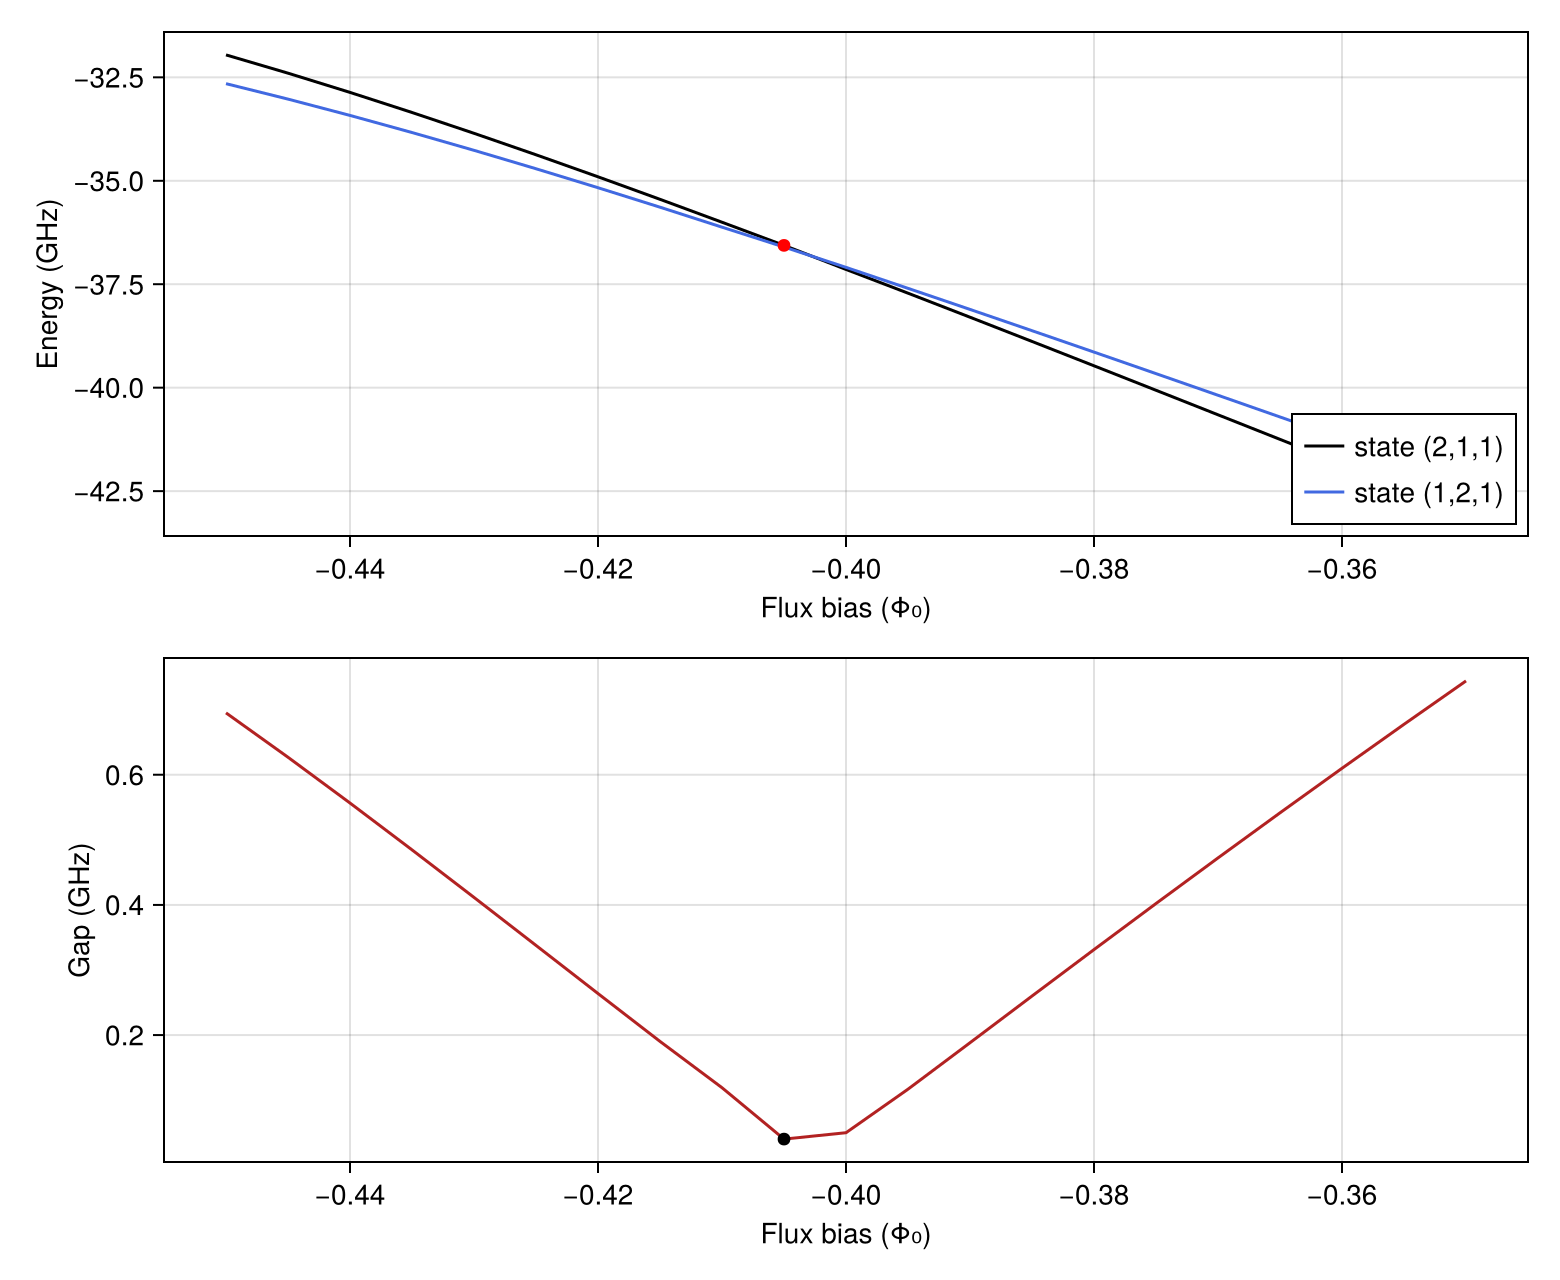

In [6]:
flux_bias = collect(range(-0.45, -0.35; length=21))
sweep_vals = 2π .* flux_bias

cross = avoided_crossing_coupling(circ;
    state_a=(2,1,1),
    state_b=(1,2,1),
    sweep_param=:Φ2,
    sweep_vals=sweep_vals,
    evals_count=16)

min_idx = argmin(cross.gap)

fig_cross = Figure(size=(780, 640))
axE = Axis(fig_cross[1,1], xlabel="Flux bias (Φ₀)", ylabel="Energy (GHz)")
lines!(axE, flux_bias, cross.tracked_energy_a, label="state (2,1,1)", color=:black)
lines!(axE, flux_bias, cross.tracked_energy_b, label="state (1,2,1)", color=:royalblue)
scatter!(axE, [cross.param_at_min_gap/(2π)], [cross.tracked_energy_a[min_idx]], color=:red)
axislegend(axE, position=:rb)

axG = Axis(fig_cross[2,1], xlabel="Flux bias (Φ₀)", ylabel="Gap (GHz)")
lines!(axG, flux_bias, cross.gap, color=:firebrick)
scatter!(axG, [cross.param_at_min_gap/(2π)], [cross.min_gap], color=:black)

fig_cross


In [7]:
println(@sprintf("Minimum gap at Φ2/(2π) = %.6f", cross.param_at_min_gap / (2π)))
println(@sprintf("min_gap = %.9f GHz", cross.min_gap))
println(@sprintf("avoided-crossing g = min_gap/2 = %.9f GHz", cross.g_half_gap))
println(@sprintf("ratio: g_half_gap / projected_g12 = %.6f", cross.g_half_gap / g_qb1_cplr))


Minimum gap at Φ2/(2π) = -0.405000
min_gap = 0.040169892 GHz
avoided-crossing g = min_gap/2 = 0.020084946 GHz
ratio: g_half_gap / projected_g12 = 1.030475


## 4) Method 3: Full Effective Hamiltonian + Pauli Decomposition

For `2-2-2`, we can decompose `H_full_eff` in the Pauli tensor basis and inspect dominant terms.


In [8]:
println("H_full_eff (real part):")
display(round.(real.(eff222.H_full_eff); digits=6))

sorted_pauli = sort(collect(eff222.pauli_terms), by=x -> abs(x[2]), rev=true)
println("Top Pauli coefficients (abs-sorted):")
for (label, coeff) in first(sorted_pauli, min(12, length(sorted_pauli)))
    println(rpad(label, 5), " => ", coeff)
end

zz_preview = zz_preview_from_diag(eff222.H_full_eff, eff222.basis_labels)
println(@sprintf("ZZ preview from diagonals (qubit1-qubit2, coupler in |0>): %.9e GHz", zz_preview))
println("Pauli coefficient ZIZ (direct preview): ", get(eff222.pauli_terms, "ZIZ", 0.0 + 0.0im))


8×8 Matrix{Float64}:
 -71.7339     -0.0         0.0       …    0.000274   -0.019491    0.0
  -0.0       -67.5931     -0.019354       0.0         0.0        -0.019491
   0.0        -0.019354  -64.4433         0.0         0.0         0.000274
  -0.019354    0.0         0.0           -0.019491    0.000274    0.0
  -0.0         0.000274   -0.019491       0.0         0.0        -0.019354
   0.000274    0.0         0.0       …  -63.3935     -0.019354   -0.0
  -0.019491    0.0         0.0           -0.019354  -60.2438      0.0
   0.0        -0.019491    0.000274      -0.0         0.0       -56.103

H_full_eff (real part):
Top Pauli coefficients (abs-sorted):
III   => -63.918418595324 + 0.0im
IZI   => -3.6452705801793233 + 0.0im
ZII   => -2.099778794068749 + 0.0im
IIZ   => -2.070408159895795 + 0.0im
XXI   => -0.019490953343518556 + 0.0im
IXX   => -0.01935438315758139 + 0.0im
XIX   => 0.00027422243262557037 + 0.0im
ZZ preview from diagonals (qubit1-qubit2, coupler in |0>): 1.421085472e-14 GHz
Pauli coefficient ZIZ (direct preview): 0.0 + 0.0im


The ZZ value here is a preview from the projected effective Hamiltonian, not a dedicated ZZ-analysis API.


## 5) Leakage-Aware Comparison (`2-3-2`)

Now keep one extra coupler level in the final projection.


In [9]:
eff232 = effective_hamiltonian(circ; projection_dims=(2,3,2), decompose_pauli=false)

println("2-3-2 matrix size: ", size(eff232.H_full_eff))
println("2-3-2 basis count: ", length(eff232.basis_labels))
println("First 12 basis labels: ", eff232.basis_labels)

g12_232 = g_from_labels(eff232.H_int_eff, eff232.basis_labels, (2,1,1), (1,2,1))
g23_232 = g_from_labels(eff232.H_int_eff, eff232.basis_labels, (1,2,1), (1,1,2))
g13_232 = g_from_labels(eff232.H_int_eff, eff232.basis_labels, (2,1,1), (1,1,2))
zz_232 = zz_preview_from_diag(eff232.H_full_eff, eff232.basis_labels)

println(@sprintf("g12 (2-2-2) = %.9f | g12 (2-3-2) = %.9f", g_qb1_cplr, g12_232))
println(@sprintf("g23 (2-2-2) = %.9f | g23 (2-3-2) = %.9f", g_cplr_qb2, g23_232))
println(@sprintf("g13 (2-2-2) = %.9f | g13 (2-3-2) = %.9f", g_qb1_qb2, g13_232))
println(@sprintf("ZZ preview (2-2-2) = %.9e | ZZ preview (2-3-2) = %.9e", zz_preview, zz_232))


2-3-2 matrix size: (12, 12)
2-3-2 basis count: 12
First 12 basis labels: [(1, 1, 1), (1, 1, 2), (1, 2, 1), (1, 2, 2), (1, 3, 1), (1, 3, 2), (2, 1, 1), (2, 1, 2), (2, 2, 1), (2, 2, 2), (2, 3, 1), (2, 3, 2)]
g12 (2-2-2) = 0.019490953 | g12 (2-3-2) = 0.019490953
g23 (2-2-2) = 0.019354383 | g23 (2-3-2) = 0.019354383
g13 (2-2-2) = 0.000274222 | g13 (2-3-2) = 0.000274222
ZZ preview (2-2-2) = 1.421085472e-14 | ZZ preview (2-3-2) = 1.421085472e-14


This comparison shows why HD truncation and final projection should remain separate knobs.


## 6) HD Convergence Note (`6-6-6` vs `8-8-8`)

Keep the final projection fixed and only increase internal HD truncation.


In [10]:
circ8 = build_yan_circuit()
configure!(circ8;
    system_hierarchy=[[1], [2], [3]],
    subsystem_trunc_dims=Dict(1 => 8, 2 => 8, 3 => 8))

eff222_8 = effective_hamiltonian(circ8; projection_dims=(2,2,2), decompose_pauli=true)

g12_8 = g_from_labels(eff222_8.H_int_eff, eff222_8.basis_labels, (2,1,1), (1,2,1))
g23_8 = g_from_labels(eff222_8.H_int_eff, eff222_8.basis_labels, (1,2,1), (1,1,2))
g13_8 = g_from_labels(eff222_8.H_int_eff, eff222_8.basis_labels, (2,1,1), (1,1,2))
zz_8 = zz_preview_from_diag(eff222_8.H_full_eff, eff222_8.basis_labels)

cross8 = avoided_crossing_coupling(circ8;
    state_a=(2,1,1),
    state_b=(1,2,1),
    sweep_param=:Φ2,
    sweep_vals=sweep_vals,
    evals_count=16)

println("Comparison summary:")
println(@sprintf("g12: default=%.9f | 8-8-8=%.9f | rel.diff=%.3e", g_qb1_cplr, g12_8, abs(g12_8 - g_qb1_cplr)/g_qb1_cplr))
println(@sprintf("g23: default=%.9f | 8-8-8=%.9f | rel.diff=%.3e", g_cplr_qb2, g23_8, abs(g23_8 - g_cplr_qb2)/g_cplr_qb2))
println(@sprintf("g13: default=%.9f | 8-8-8=%.9f | rel.diff=%.3e", g_qb1_qb2, g13_8, abs(g13_8 - g_qb1_qb2)/max(g_qb1_qb2, 1e-15)))
println(@sprintf("ZZ preview: default=%.9e | 8-8-8=%.9e", zz_preview, zz_8))
println(@sprintf("avoided-crossing g_half_gap: default=%.9f | 8-8-8=%.9f", cross.g_half_gap, cross8.g_half_gap))


Comparison summary:
g12: default=0.019490953 | 8-8-8=0.019490953 | rel.diff=0.000e+00
g23: default=0.019354383 | 8-8-8=0.019354383 | rel.diff=0.000e+00
g13: default=0.000274222 | 8-8-8=0.000274222 | rel.diff=0.000e+00
ZZ preview: default=1.421085472e-14 | 8-8-8=1.421085472e-14
avoided-crossing g_half_gap: default=0.020084946 | 8-8-8=0.020084946


For future ZZ analysis, convergence checks should be done against **HD truncation** first,
not only against the final projection choice (`2-2-2` vs `2-3-2`).
